# Forecasting Analysis

This notebook uses `src/forecasting.py` as the single source of truth for the forecasting workflow.

It evaluates short-term forecasts for `daily_revenue` and `daily_order_volume` with Seasonal Naive and additive Holt-Winters, then uses the lower-RMSE model for the next 30 days.

The notebook now includes visuals for the historical signal, weekly operating rhythm, model comparison, and the near-term forecast outlook.


## Notebook Setup

The next cell imports the forecasting helpers from `src/forecasting.py`, loads the plotting libraries used for the visuals, and defines the shared colors and axis formatters used throughout the notebook.


In [8]:
"""Import forecasting utilities and plotting dependencies for the notebook."""

from datetime import date
from pathlib import Path
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

root = Path.cwd().resolve()
project_root = root.parent if root.name == "notebooks" else root
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from forecasting import (
    DATA_PATH,
    FORECAST_DAYS,
    TEST_DAYS,
    evaluate_target,
    load_daily_targets,
    render_table,
    summarize_forecast,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
    }
)


def format_currency(value, _position):
    return f"${value / 1000:.0f}k"


def format_integer(value, _position):
    return f"{value:.0f}"


TARGET_META = {
    "daily_revenue": {
        "label": "Daily revenue",
        "short_label": "Revenue",
        "color": "#0f766e",
        "unit": "Revenue",
        "axis_formatter": FuncFormatter(format_currency),
    },
    "daily_order_volume": {
        "label": "Daily order volume",
        "short_label": "Orders",
        "color": "#2563eb",
        "unit": "Orders",
        "axis_formatter": FuncFormatter(format_integer),
    },
}

MODEL_COLORS = {
    "Seasonal Naive": "#1d4ed8",
    "Holt-Winters": "#f97316",
}


## Load And Prepare Daily Targets

The cleaned transactional dataset is aggregated into two daily time series:
- `daily_revenue`
- `daily_order_volume`

Missing dates are kept and treated as zero-activity days so the model can learn the weekly operating pattern.

The next cell loads those prepared series and prints the time span, target names, and forecast windows used in the rest of the notebook.


In [9]:
"""Load the prepared daily targets and inspect the forecasting window."""

dates, targets = load_daily_targets(DATA_PATH)
target_names = list(targets.keys())

print(f"Observations: {len(dates)} daily records")
print(f"Date range: {dates[0].isoformat()} to {dates[-1].isoformat()}")
print("Targets:", ", ".join(target_names))
print(f"Holdout window: last {TEST_DAYS} days")
print(f"Forecast horizon: next {FORECAST_DAYS} days")


Observations: 374 daily records
Date range: 2010-12-01 to 2011-12-09
Targets: daily_revenue, daily_order_volume
Holdout window: last 30 days
Forecast horizon: next 30 days


## Historical Signal

These charts show the full daily history, including the raw observations, a 7-day smoothing line, and the recurring zero-activity days that shape the weekly seasonality.

The next cell plots both targets across the full date range so the level shifts, volatility, and repeated zero-activity days are visible at a glance.


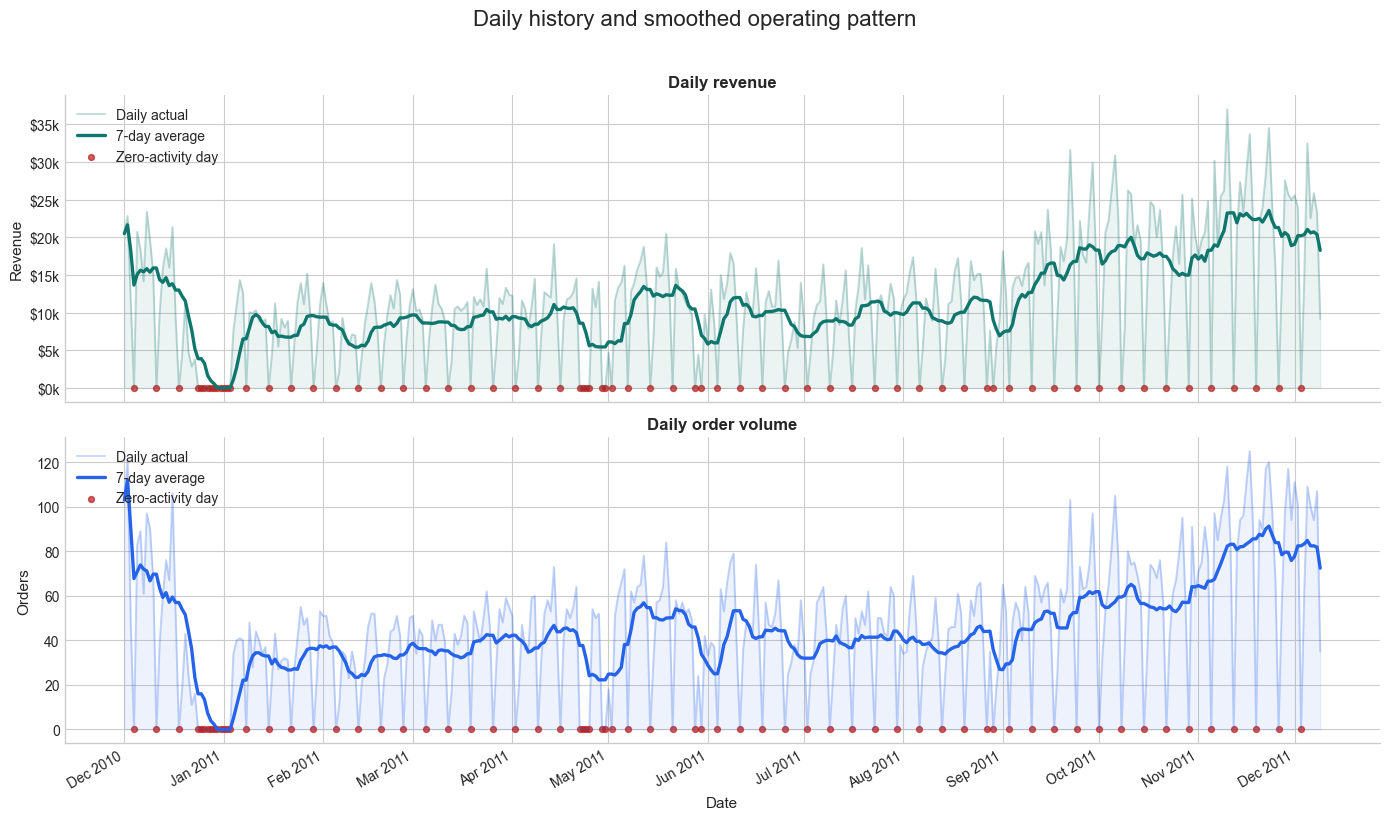

In [10]:
"""Plot the full daily history to highlight volatility, seasonality, and zero-activity days."""

rolling_window = 7


def moving_average(values, window):
    averages = []
    for index in range(len(values)):
        start = max(0, index - window + 1)
        window_values = values[start : index + 1]
        averages.append(sum(window_values) / len(window_values))
    return averages


fig, axes = plt.subplots(len(target_names), 1, figsize=(14, 8), sharex=True)

for axis, target_name in zip(axes, target_names):
    series = targets[target_name]
    meta = TARGET_META[target_name]
    smoothed = moving_average(series, rolling_window)

    axis.plot(dates, series, color=meta["color"], alpha=0.25, linewidth=1.4, label="Daily actual")
    axis.plot(dates, smoothed, color=meta["color"], linewidth=2.4, label=f"{rolling_window}-day average")
    axis.fill_between(dates, series, color=meta["color"], alpha=0.08)

    zero_days = [current_date for current_date, value in zip(dates, series) if value == 0]
    if zero_days:
        axis.scatter(zero_days, [0] * len(zero_days), color="#b91c1c", s=18, alpha=0.7, label="Zero-activity day")

    axis.set_title(meta["label"])
    axis.set_ylabel(meta["unit"])
    axis.yaxis.set_major_formatter(meta["axis_formatter"])
    axis.legend(loc="upper left")

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.suptitle("Daily history and smoothed operating pattern", fontsize=16, y=1.02)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Weekly Demand Profile

This view condenses the full history into average weekday behavior, which makes the repeating operational rhythm easier to scan than the raw time series alone.

The next cell calculates the average value for each weekday and plots the typical weekly shape for revenue and order volume.


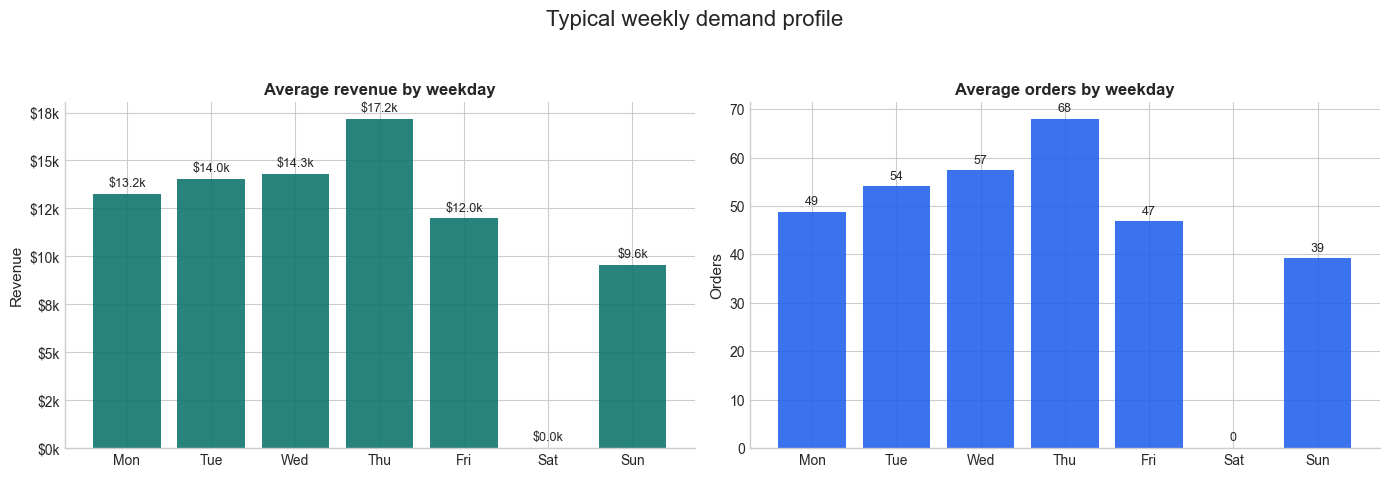

In [11]:
"""Summarize the average weekly operating profile for revenue and order volume."""

weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, len(target_names), figsize=(14, 4.5), sharey=False)

for axis, target_name in zip(axes, target_names):
    meta = TARGET_META[target_name]
    weekday_groups = {index: [] for index in range(7)}

    for current_date, value in zip(dates, targets[target_name]):
        weekday_groups[current_date.weekday()].append(value)

    weekday_averages = [
        sum(weekday_groups[index]) / len(weekday_groups[index])
        for index in range(7)
    ]

    bars = axis.bar(weekday_names, weekday_averages, color=meta["color"], alpha=0.9)
    axis.bar_label(
        bars,
        labels=[
            f"${value / 1000:.1f}k" if target_name == "daily_revenue" else f"{value:.0f}"
            for value in weekday_averages
        ],
        padding=3,
        fontsize=9,
    )
    axis.set_title(f"Average {meta['short_label'].lower()} by weekday")
    axis.set_ylabel(meta["unit"])
    axis.yaxis.set_major_formatter(meta["axis_formatter"])
    axis.set_ylim(bottom=0)

fig.suptitle("Typical weekly demand profile", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


## Evaluate Competing Forecast Models

Each target is split chronologically:
- training set: all observations except the final 30 days
- test set: the final 30 days

The notebook scores both models with MAE, RMSE, and WAPE.

`Accuracy` is not used here because both targets are continuous regression outputs rather than class labels.

The next cell runs the holdout evaluation for each target, collects the future forecasts, and prints the metric table used for model selection.


In [12]:
"""Evaluate each target, compare models, and collect future forecasts."""

all_metrics = []
all_forecasts = []
all_summaries = []

for target_name, series in targets.items():
    target_metrics, target_forecasts = evaluate_target(target_name, series, dates)
    all_metrics.extend(target_metrics)
    all_forecasts.extend(target_forecasts)
    all_summaries.append(
        summarize_forecast(
            target_name,
            target_forecasts[0]["model"],
            [row["forecast"] for row in target_forecasts],
        )
    )

print("Model evaluation:")
print(render_table(all_metrics, ["target", "model", "mae", "rmse", "wape"]))


Model evaluation:
target              model           mae       rmse      wape 
------------------  --------------  --------  --------  -----
daily_revenue       Seasonal Naive  5822.61   8048.46   27.42
daily_revenue       Holt-Winters    13193.88  15816.71  62.14
daily_order_volume  Seasonal Naive  14.70     19.06     17.84
daily_order_volume  Holt-Winters    56.81     67.30     68.94


## Model Comparison Visual

The grouped charts below make it easier to compare the two candidate models across all holdout metrics without scanning the table cell by cell.

The next cell turns the MAE, RMSE, and WAPE results into grouped bar charts so the gap between the baseline and Holt-Winters is easier to interpret.


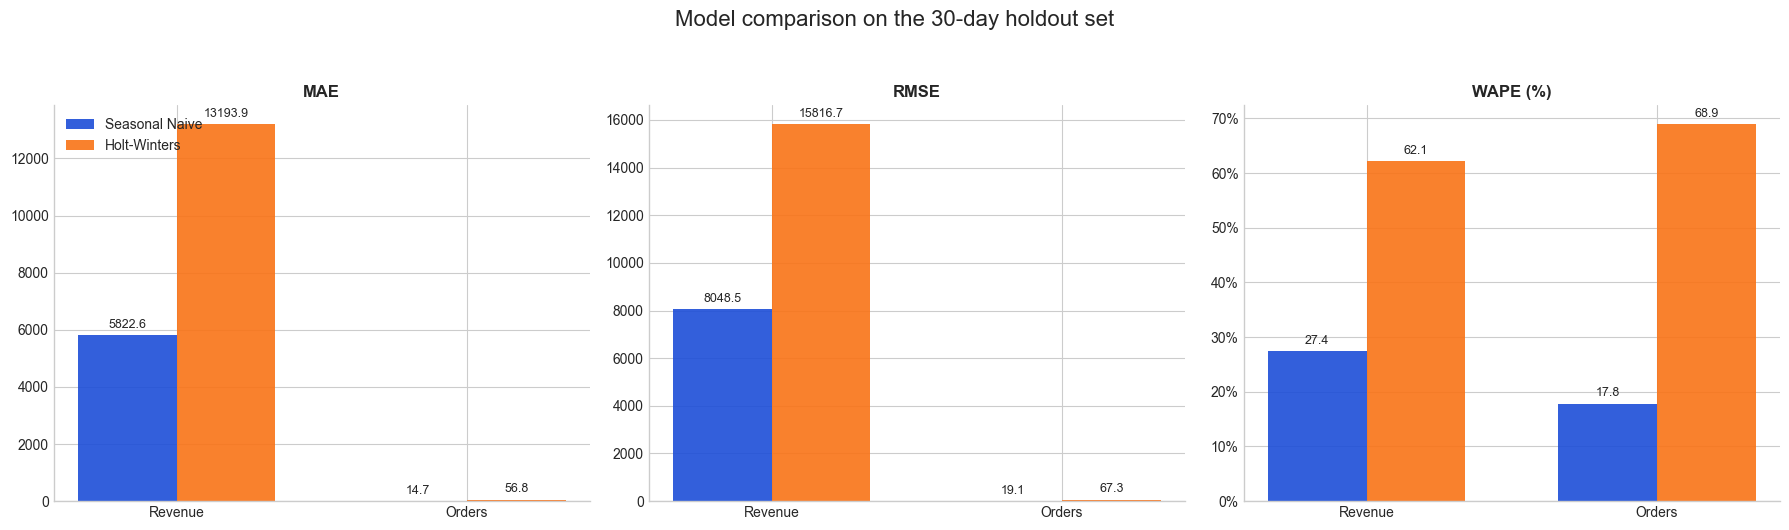

In [13]:
"""Visualize the holdout-set metrics for each candidate model."""

metric_names = ["mae", "rmse", "wape"]
metric_titles = {"mae": "MAE", "rmse": "RMSE", "wape": "WAPE (%)"}
target_positions = list(range(len(target_names)))
bar_width = 0.34

fig, axes = plt.subplots(1, len(metric_names), figsize=(18, 5), sharey=False)

for axis, metric_name in zip(axes, metric_names):
    for offset, model_name in enumerate(MODEL_COLORS):
        model_values = []
        for target_name in target_names:
            metric_row = next(
                row
                for row in all_metrics
                if row["target"] == target_name and row["model"] == model_name
            )
            model_values.append(metric_row[metric_name])

        bar_positions = [position + (offset - 0.5) * bar_width for position in target_positions]
        bars = axis.bar(
            bar_positions,
            model_values,
            width=bar_width,
            color=MODEL_COLORS[model_name],
            alpha=0.9,
            label=model_name,
        )
        axis.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

    axis.set_title(metric_titles[metric_name])
    axis.set_xticks(target_positions, [TARGET_META[name]["short_label"] for name in target_names])
    if metric_name == "wape":
        axis.yaxis.set_major_formatter(FuncFormatter(lambda value, _position: f"{value:.0f}%"))

axes[0].legend(loc="upper left")
fig.suptitle("Model comparison on the 30-day holdout set", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


## Forecast Summary

The forward forecast uses the lower-RMSE model for each target. In the current dataset, Seasonal Naive is selected because it outperforms Holt-Winters on both revenue and order volume.

The next cell prints the selected-model forecast totals and a short preview of the first 7 forecasted days for both targets.


In [14]:
"""Summarize the selected 30-day forecasts and preview the next week."""

print("30-day forecast summary:")
print(
    render_table(
        all_summaries,
        [
            "target",
            "selected_model",
            "30_day_total_forecast",
            "average_daily_forecast",
            "peak_day_forecast",
        ],
    )
)

preview_rows = []
seen_by_target = {}
for row in all_forecasts:
    seen_by_target.setdefault(row["target"], 0)
    if seen_by_target[row["target"]] < 7:
        preview_rows.append(row)
        seen_by_target[row["target"]] += 1

print()
print("Next 7 forecasted days:")
print(render_table(preview_rows, ["date", "target", "model", "forecast"]))


30-day forecast summary:
target              selected_model  30_day_total_forecast  average_daily_forecast  peak_day_forecast
------------------  --------------  ---------------------  ----------------------  -----------------
daily_revenue       Seasonal Naive  526053.01              17535.10                32482.45         
daily_order_volume  Seasonal Naive  2090.00                69.67                   109.00           

Next 7 forecasted days:
date        target              model           forecast
----------  ------------------  --------------  --------
2011-12-10  daily_revenue       Seasonal Naive  0.00    
2011-12-11  daily_revenue       Seasonal Naive  14558.65
2011-12-12  daily_revenue       Seasonal Naive  32482.45
2011-12-13  daily_revenue       Seasonal Naive  22549.66
2011-12-14  daily_revenue       Seasonal Naive  25878.46
2011-12-15  daily_revenue       Seasonal Naive  23294.46
2011-12-16  daily_revenue       Seasonal Naive  9109.91 
2011-12-10  daily_order_volume  S

## Forecast Outlook Visual

These charts place the selected 30-day forecast next to the most recent 60 days of actual observations. The dotted divider marks the point where the forecast begins, and the shaded area shows the forward horizon.

The next cell overlays the chosen forecast on top of recent history so the transition from observed values to projected values is easy to see.


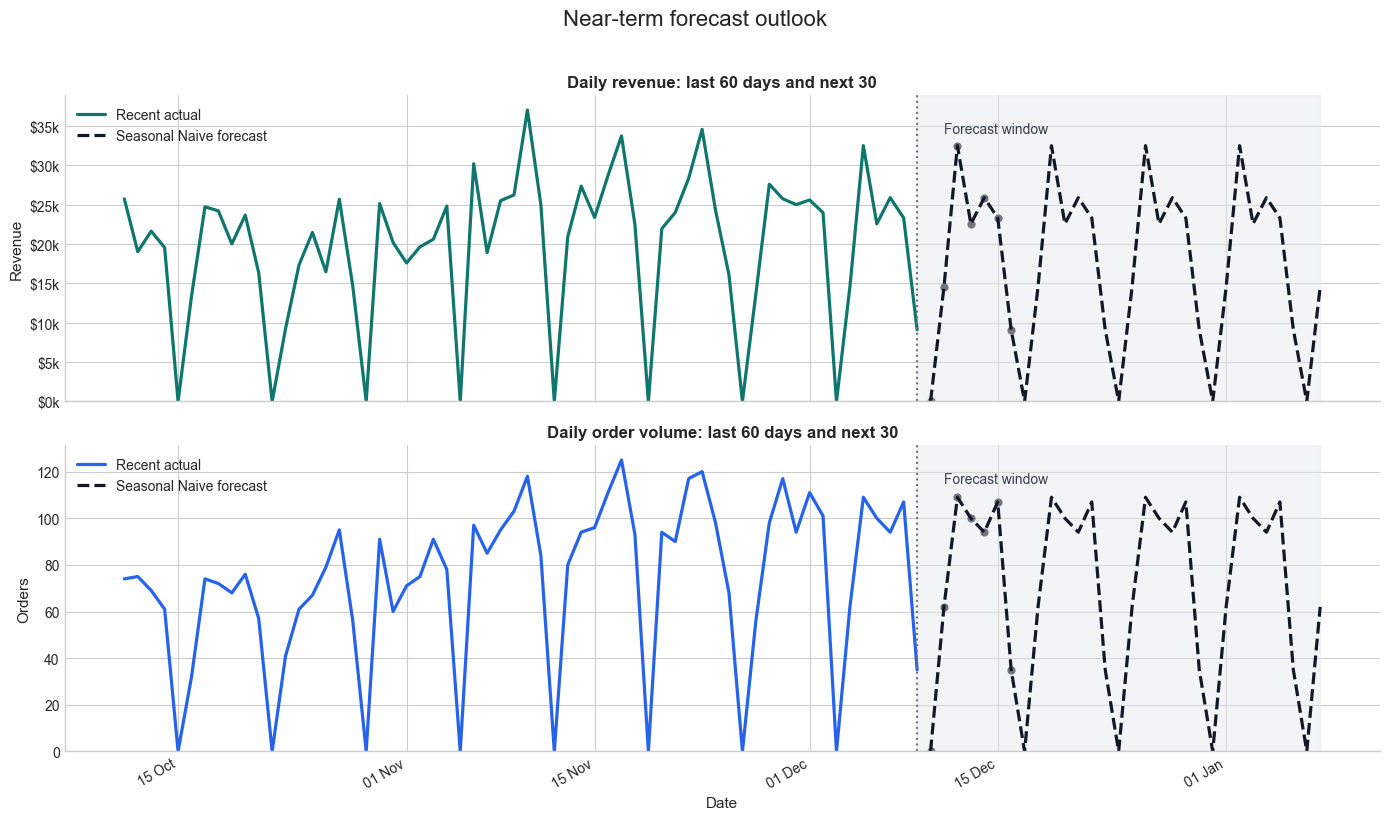

In [15]:
"""Plot the recent history against the selected 30-day forecast for each target."""

history_window = 60
fig, axes = plt.subplots(len(target_names), 1, figsize=(14, 8), sharex=False)

for axis, target_name in zip(axes, target_names):
    meta = TARGET_META[target_name]
    history_dates = dates[-history_window:]
    history_values = targets[target_name][-history_window:]
    target_forecast_rows = [row for row in all_forecasts if row["target"] == target_name]
    future_dates = [date.fromisoformat(row["date"]) for row in target_forecast_rows]
    future_values = [row["forecast"] for row in target_forecast_rows]
    selected_model = target_forecast_rows[0]["model"]

    axis.plot(history_dates, history_values, color=meta["color"], linewidth=2.3, label="Recent actual")
    axis.plot(
        future_dates,
        future_values,
        color="#111827",
        linewidth=2.3,
        linestyle="--",
        label=f"{selected_model} forecast",
    )
    axis.scatter(future_dates[:7], future_values[:7], color="#111827", s=24)
    axis.axvline(dates[-1], color="#6b7280", linestyle=":", linewidth=1.5)
    axis.axvspan(dates[-1], future_dates[-1], color="#e5e7eb", alpha=0.45)
    axis.text(
        future_dates[1],
        max(max(history_values), max(future_values)) * 0.92,
        "Forecast window",
        color="#374151",
        fontsize=10,
    )

    axis.set_title(f"{meta['label']}: last {history_window} days and next {FORECAST_DAYS}")
    axis.set_ylabel(meta["unit"])
    axis.set_ylim(bottom=0)
    axis.yaxis.set_major_formatter(meta["axis_formatter"])
    axis.legend(loc="upper left")
    axis.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=10))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

axes[-1].set_xlabel("Date")
fig.suptitle("Near-term forecast outlook", fontsize=16, y=1.02)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Forecasted Trends

The short narrative below is generated from the computed forecast tables so the explanation stays in sync with the model output.

The next cell converts the selected forecast outputs into a short operational summary that can be reused in the report or presentation.


In [16]:
"""Turn the selected forecasts into a short operational narrative."""

summary_lookup = {row["target"]: row for row in all_summaries}

revenue_summary = summary_lookup["daily_revenue"]
volume_summary = summary_lookup["daily_order_volume"]
revenue_preview = [row for row in preview_rows if row["target"] == "daily_revenue"]
volume_preview = [row for row in preview_rows if row["target"] == "daily_order_volume"]

zero_revenue_days = [row["date"] for row in revenue_preview if row["forecast"] == 0]
peak_revenue_day = max(revenue_preview, key=lambda row: row["forecast"])
peak_volume_day = max(volume_preview, key=lambda row: row["forecast"])

print("Forecasted trends:")
print(
    f"- Revenue is projected at {revenue_summary['30_day_total_forecast']:.2f} over the next 30 days, "
    f"averaging {revenue_summary['average_daily_forecast']:.2f} per day."
)
print(
    f"- Order volume is projected at {volume_summary['30_day_total_forecast']:.0f} orders over the next 30 days, "
    f"averaging {volume_summary['average_daily_forecast']:.2f} orders per day."
)
print(
    f"- The next week repeats a weekly cycle, with zero-revenue days on {', '.join(zero_revenue_days)} "
    f"and a peak on {peak_revenue_day['date']} ({peak_revenue_day['forecast']:.2f} revenue; "
    f"{peak_volume_day['forecast']:.0f} orders)."
)


Forecasted trends:
- Revenue is projected at 526053.01 over the next 30 days, averaging 17535.10 per day.
- Order volume is projected at 2090 orders over the next 30 days, averaging 69.67 orders per day.
- The next week repeats a weekly cycle, with zero-revenue days on 2011-12-10 and a peak on 2011-12-12 (32482.45 revenue; 109 orders).


## Operational Impact

Short-term forecasts from this notebook can be used to:
- plan staffing for order-processing peaks
- prepare replenishment for higher-demand days
- estimate near-term revenue for tactical cash-flow decisions

The main limitation is that the model only sees transaction history. Promotions, holidays, and supply disruptions are not included, so the forecasts should be used as tactical guidance rather than a long-range plan.
